# Multi-Class Classification for SDN Traffic Types

Multi-class classification of network traffic in an SDN environment to optimize Quality of Service (QoS).

Based on the research paper, we have implemented three machine learning models, including XGBoost, which was found to be the most effective.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install xgboost
    from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\rohit\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.1/101.7 MB 1.3 MB/s eta 0:01:17
     ---------------------------------------- 0.2/101.7 MB 2.5 MB/s eta 0:00:41
     ---------------------------------------- 0.5/101.7 MB 4.2 MB/s eta 0:00:25
      -------------------------------------- 1.8/101.7 MB 10.6 MB/s eta 0:00:10
     - ------------------------------------- 4.2/101.7 MB 19.1 MB/s eta 0:00:06
     -- ------------------------------------ 7.0/101.7 MB 26.1 MB/s eta 0:00:04
     --- ----------------------------------- 8.0/101.7 MB 28.4 MB/s eta 0:00:04
     --- ----------------------------------- 8.0/101.7 MB 28.4 MB/s eta 0:00:04
     --- ----------------------------------- 8.1/101.7 MB 20.0 MB/s eta 0:00:05
     ---- --------------------------------- 10.9/101.7 MB 29.7 MB/s eta 0:00:04
     ---- --------------------------------- 12.5/101.7 MB 31.2 MB/s eta 0:00:03
     ---- --------------------------------- 13.

## 1. Load the Dataset

In [2]:
# Load the normal traffic dataset
df = pd.read_csv('SDNFlow_Dataset_Normal.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (221564, 39)


,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,1,2048,192.168.56.201,192.168.56.1,6,22,41410,6.472,113472,628,...,0.0,113472,7295988,628,6659,628,1,10,0,SSH
1,2,2048,192.168.56.1,192.168.56.201,6,41410,22,6.465,24492,370,...,0.0,26080,24492,381,370,370,2,1,0,SSH
2,3,2048,192.168.56.203,192.168.56.201,1,0,0,4.798,2211,4,...,0.0,28291,3799,385,15,0,3,2,0,ICMP
3,4,2048,192.168.56.201,192.168.56.203,17,57426,1236,595.270,10827817,25627,...,0.0,188960322,180776253,157117,153898,30743,60,19,0,STREAMING
4,5,2048,192.168.56.201,192.168.56.203,17,48549,1234,595.251,154551644,114704,...,0.0,188960322,180776253,157117,153898,122654,60,19,0,STREAMING


## 2. Preprocessing

The Following steps are done :

- Drop constant columns (`eth_type`, `Attack`)
- Drop identifier columns (`flow_ID`)
- Encode categorical features (`ipv4_src`, `ipv4_dst`, `Category`)
- Scale numerical features using MinMaxScaler 

In [3]:
# Dropping columns with single unique value or redundant info
to_drop = ['flow_ID', 'eth_type', 'Attack']
df.drop(columns=to_drop, inplace=True)

# Label Encoding for categorical columns
le_src = LabelEncoder()
le_dst = LabelEncoder()
le_cat = LabelEncoder()

df['ipv4_src'] = le_src.fit_transform(df['ipv4_src'])
df['ipv4_dst'] = le_dst.fit_transform(df['ipv4_dst'])
df['Category'] = le_cat.fit_transform(df['Category'])

print("Encodings for Category:")
mapping = dict(zip(le_cat.classes_, le_cat.transform(le_cat.classes_)))
print(mapping)

# Identifing features and target
X = df.drop(columns=['Category'])
y = df['Category']

# Scaling numerical features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

Encodings for Category:
{'DNS': np.int64(0), 'FTP': np.int64(1), 'HTTP': np.int64(2), 'ICMP': np.int64(3), 'NTP': np.int64(4), 'SSH': np.int64(5), 'STREAMING': np.int64(6)}


## 3. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (177251, 35)
Testing set size: (44313, 35)


## 4. Model Training & Evaluation

We will test three models:
1. **Decision Tree**
2. **Random Forest**
3. **XGBoost** 


--- Decision Tree ---
Accuracy: 0.9998
Classification Report:
              precision    recall  f1-score   support

         DNS       1.00      1.00      1.00     10710
         FTP       1.00      1.00      1.00        18
        HTTP       1.00      1.00      1.00     32995
        ICMP       1.00      1.00      1.00        61
         NTP       0.44      0.80      0.57         5
         SSH       1.00      1.00      1.00       227
   STREAMING       1.00      0.99      0.99       297

    accuracy                           1.00     44313
   macro avg       0.92      0.97      0.94     44313
weighted avg       1.00      1.00      1.00     44313



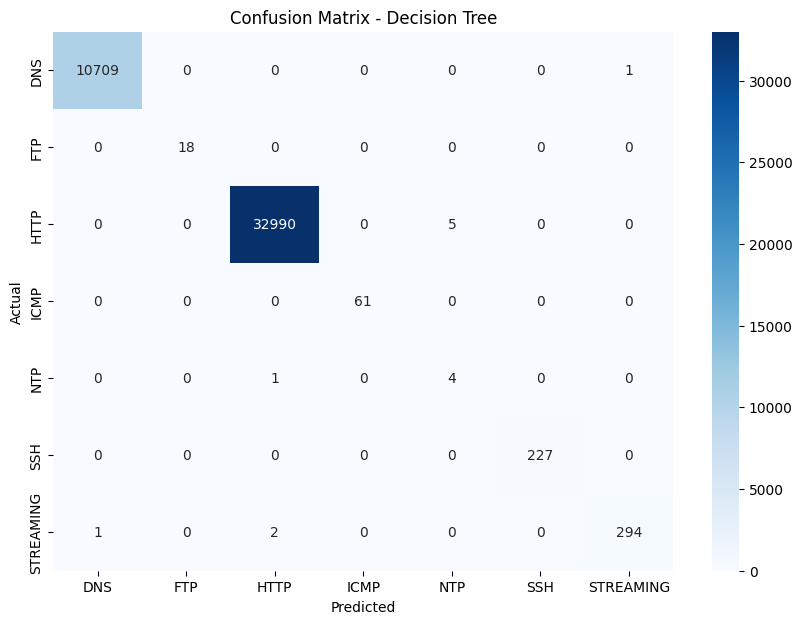


--- Random Forest ---
Accuracy: 0.9999
Classification Report:
              precision    recall  f1-score   support

         DNS       1.00      1.00      1.00     10710
         FTP       1.00      1.00      1.00        18
        HTTP       1.00      1.00      1.00     32995
        ICMP       1.00      1.00      1.00        61
         NTP       0.50      0.20      0.29         5
         SSH       1.00      1.00      1.00       227
   STREAMING       1.00      1.00      1.00       297

    accuracy                           1.00     44313
   macro avg       0.93      0.89      0.90     44313
weighted avg       1.00      1.00      1.00     44313



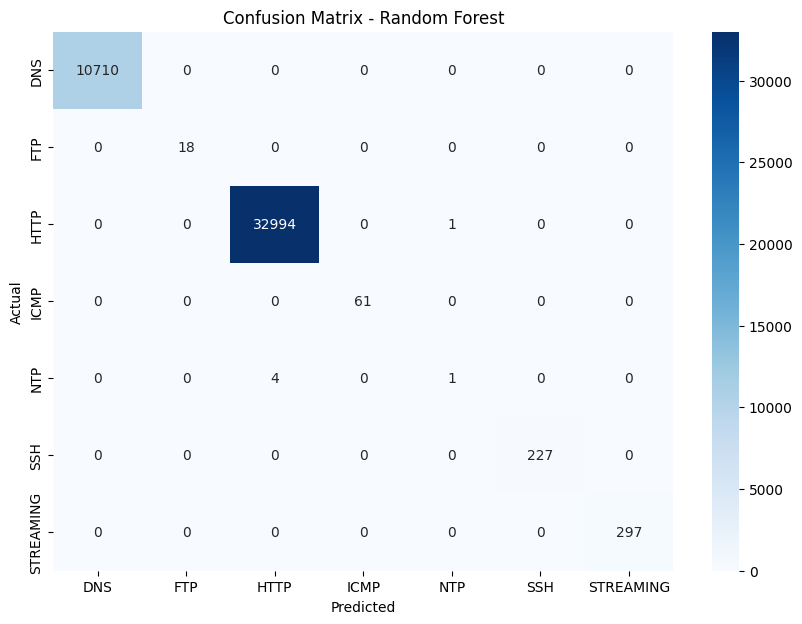


--- XGBoost ---
Accuracy: 0.9999
Classification Report:
              precision    recall  f1-score   support

         DNS       1.00      1.00      1.00     10710
         FTP       1.00      1.00      1.00        18
        HTTP       1.00      1.00      1.00     32995
        ICMP       1.00      1.00      1.00        61
         NTP       1.00      0.20      0.33         5
         SSH       1.00      1.00      1.00       227
   STREAMING       1.00      1.00      1.00       297

    accuracy                           1.00     44313
   macro avg       1.00      0.89      0.90     44313
weighted avg       1.00      1.00      1.00     44313



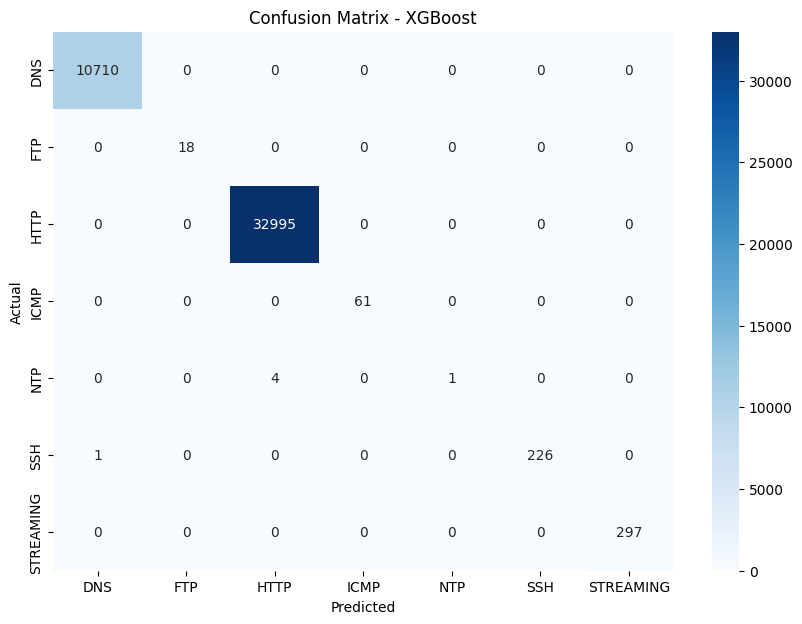

In [5]:
def evaluate_model(model, name):
    print(f"\n--- {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le_cat.classes_))
    
    # Confusion Matrix
    plt.figure(figsize=(10, 7))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le_cat.classes_, yticklabels=le_cat.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# 1. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
evaluate_model(dt, "Decision Tree")

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model(rf, "Random Forest")

# 3. XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
evaluate_model(xgb, "XGBoost")

## 5. Conclusion

As demonstrated by the results, the models perform exceptionally well on the SDN traffic dataset. Accurate traffic classification enables the SDN controller to apply specific QoS policies and prioritize time-sensitive traffic like STREAMING over background traffic like FTP or NTP.